# Homework 11 — Evaluation & Risk Communication

**Author:** Paritosh Dwivedi

Quantify uncertainty with a bootstrap, compare two competing assumptions, check subgroups for hidden
failure, and write the result in language a stakeholder can act on.

Helpers live in `src/evaluation.py` and are imported rather than defined inline. `SEED = 42`.

## 1. Data

SPY daily history saved to `data/raw/`, then a feature table to `data/processed/`. Raw stays immutable; anything derived is re-creatable.

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf
from sklearn.linear_model import LinearRegression

import sys
sys.path.insert(0, '.')
from src.evaluation import bootstrap_ci, gaussian_ci, mae, rmse, subgroup_metrics

warnings.filterwarnings('ignore')
SEED = 42
TRADING_DAYS = 252
np.random.seed(SEED)

RAW = Path('data/raw'); PROC = Path('data/processed')
RAW.mkdir(parents=True, exist_ok=True); PROC.mkdir(parents=True, exist_ok=True)

raw_path = RAW / 'spy_daily_stage11.csv'
if raw_path.exists():
    prices = pd.read_csv(raw_path, parse_dates=['date']).set_index('date')
    print(f'loaded cached snapshot: {raw_path}')
else:
    dl = yf.download('SPY', start='2015-01-01', end='2026-08-26', auto_adjust=True, progress=False)
    if isinstance(dl.columns, pd.MultiIndex):
        dl.columns = dl.columns.get_level_values(0)
    prices = dl.rename(columns=str.lower)[['close', 'volume']].dropna()
    prices.index.name = 'date'
    prices.to_csv(raw_path)
    print(f'acquired and saved: {raw_path}')
print(f'{len(prices):,} sessions')

loaded cached snapshot: data/raw/spy_daily_stage11.csv
2,928 sessions


In [2]:
df = prices.copy()
df['ret'] = df['close'].pct_change()
df['rolling_vol_5'] = df['ret'].rolling(5).std() * np.sqrt(TRADING_DAYS)
df['rolling_vol_20'] = df['ret'].rolling(20).std() * np.sqrt(TRADING_DAYS)
df['ewma_vol_20'] = df['ret'].ewm(span=20).std() * np.sqrt(TRADING_DAYS)
df['drawdown'] = df['close'] / df['close'].cummax() - 1.0
# forward target: t+1..t+5  (rolling then shift(-5); shift(-1).rolling would overlap the past)
df['target_vol'] = df['ret'].rolling(5).std().shift(-5) * np.sqrt(TRADING_DAYS)

# subgroup label for the diagnostic later: volatility regime, cut on TRAINING quantiles only
FEATURES = ['rolling_vol_5', 'rolling_vol_20', 'ewma_vol_20', 'drawdown']
model_df = df.dropna(subset=FEATURES + ['target_vol']).copy()
model_df.to_parquet(PROC / 'stage11_model_dataset.parquet')
print(f'saved {PROC / "stage11_model_dataset.parquet"}  ({len(model_df):,} rows)')
model_df[FEATURES + ['target_vol']].tail(3).round(4)

saved data/processed/stage11_model_dataset.parquet  (2,903 rows)


,rolling_vol_5,rolling_vol_20,ewma_vol_20,drawdown,target_vol
date,,,,,
2026-08-14,0.0645,0.1336,0.1212,-0.0020,0.0877
2026-08-17,0.0759,0.1352,0.1198,-0.0067,0.0861
2026-08-18,0.0883,0.1365,0.1205,-0.0134,0.0832


## 2. Baseline fit and residuals

Time-ordered 75/25 split, so the test period is genuinely unseen.

In [3]:
cut = int(len(model_df) * 0.75)
train, test = model_df.iloc[:cut].copy(), model_df.iloc[cut:].copy()

model = LinearRegression().fit(train[FEATURES], train['target_vol'])
test['pred'] = model.predict(test[FEATURES])
test['resid'] = test['target_vol'] - test['pred']

# regime label from TRAINING quantiles, applied to test -- no test information used to define it
q33, q66 = train['rolling_vol_20'].quantile([0.33, 0.66])
test['regime'] = pd.cut(test['rolling_vol_20'], [-np.inf, q33, q66, np.inf],
                        labels=['calm', 'normal', 'stressed'])

print(f'train {len(train):,}   test {len(test):,}')
print(f'MAE  {mae(test["target_vol"], test["pred"]):.4f}')
print(f'RMSE {rmse(test["target_vol"], test["pred"]):.4f}')

train 2,177   test 726
MAE  0.0498
RMSE 0.0848


## 3. Bootstrap the metric

1,000 paired resamples of the holdout. This answers *how precisely the score is known*, not whether the model is right.

In [4]:
boot_mae = bootstrap_ci(test['target_vol'], test['pred'], mae, resamples=1000, seed=SEED)
gauss_mae = gaussian_ci(test['target_vol'], test['pred'], mae)

ci_table = pd.DataFrame([boot_mae, gauss_mae]).set_index('method')[['point', 'lo', 'hi']]
ci_table['width'] = ci_table['hi'] - ci_table['lo']
ci_table.round(5)

,point,lo,hi,width
method,,,,
bootstrap percentile,0.0498,0.04502,0.05474,0.00972
gaussian approximation,0.0498,0.04480,0.05479,0.01000


## 4. Scenario comparison — two competing assumptions

**Scenario A: Gaussian vs bootstrap confidence interval.** Same data, two ways of saying how
precisely MAE is known.

**Scenario B: linear vs polynomial model form.** Same data, two functional-form assumptions.

In [5]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures

poly = make_pipeline(PolynomialFeatures(degree=2, include_bias=False), LinearRegression())
poly.fit(train[FEATURES], train['target_vol'])
test['pred_poly'] = poly.predict(test[FEATURES])

boot_poly = bootstrap_ci(test['target_vol'], test['pred_poly'], mae, resamples=1000, seed=SEED)
scenario_b = pd.DataFrame([
    {'model form': 'linear', **{k: boot_mae[k] for k in ('point', 'lo', 'hi')}},
    {'model form': 'polynomial (deg 2)', **{k: boot_poly[k] for k in ('point', 'lo', 'hi')}},
]).set_index('model form')
scenario_b['delta_vs_linear'] = scenario_b['point'] - boot_mae['point']
scenario_b.round(5)

,point,lo,hi,delta_vs_linear
model form,,,,
linear,0.04980,0.04502,0.05474,0.00000
polynomial (deg 2),0.05049,0.04540,0.05596,0.00069


## 5. Subgroup diagnostic

Metrics per volatility regime. An aggregate can look fine while one regime fails badly.

In [6]:
groups = subgroup_metrics(test, 'regime', 'target_vol', 'pred')
groups.round(4)

,regime,n,mae,rmse,mean_residual
0,calm,164,0.0495,0.0673,0.0217
1,normal,457,0.0375,0.0484,-0.0028
2,stressed,105,0.1036,0.1802,-0.0028


## 6. Visuals

Side-by-side panels, shared axes where comparable, each captioned with its assumption and its takeaway.

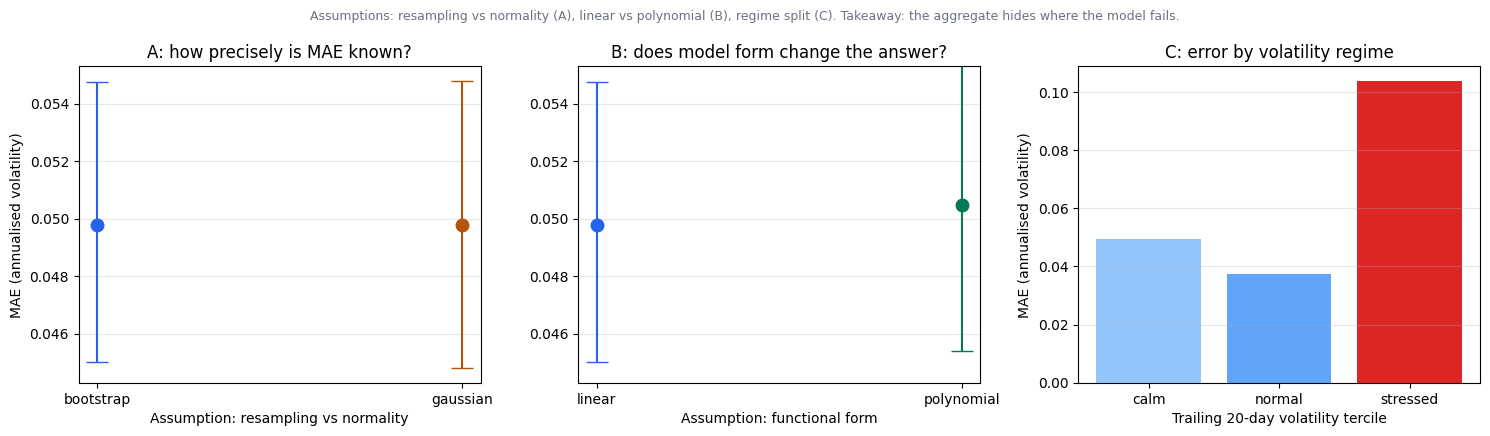

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))

# panel 1 -- scenario A: interval methods
for i, (name, row) in enumerate(ci_table.iterrows()):
    axes[0].errorbar(i, row['point'],
                     yerr=[[row['point'] - row['lo']], [row['hi'] - row['point']]],
                     fmt='o', capsize=8, markersize=9,
                     color='#2563EB' if i == 0 else '#B45309')
axes[0].set_xticks(range(len(ci_table)))
axes[0].set_xticklabels(['bootstrap', 'gaussian'])
axes[0].set_title('A: how precisely is MAE known?')
axes[0].set_ylabel('MAE (annualised volatility)')
axes[0].set_xlabel('Assumption: resampling vs normality')

# panel 2 -- scenario B: model form, same y-axis as panel 1 for comparability
for i, (name, row) in enumerate(scenario_b.iterrows()):
    axes[1].errorbar(i, row['point'],
                     yerr=[[row['point'] - row['lo']], [row['hi'] - row['point']]],
                     fmt='o', capsize=8, markersize=9,
                     color='#2563EB' if i == 0 else '#047857')
axes[1].set_xticks(range(len(scenario_b)))
axes[1].set_xticklabels(['linear', 'polynomial'])
axes[1].set_title('B: does model form change the answer?')
axes[1].set_xlabel('Assumption: functional form')
axes[1].set_ylim(axes[0].get_ylim())          # shared scale with panel 1

# panel 3 -- subgroup
axes[2].bar(groups['regime'].astype(str), groups['mae'], color=['#93C5FD', '#60A5FA', '#DC2626'])
axes[2].set_title('C: error by volatility regime')
axes[2].set_ylabel('MAE (annualised volatility)')
axes[2].set_xlabel('Trailing 20-day volatility tercile')

for ax in axes:
    ax.grid(axis='y', alpha=0.3)
fig.suptitle('Assumptions: resampling vs normality (A), linear vs polynomial (B), regime split (C). '
             'Takeaway: the aggregate hides where the model fails.', fontsize=9, color='#6B7280')
fig.tight_layout()
plt.show()

## 7. Stakeholder summary

**What the model does.** It forecasts how volatile the next five trading sessions are likely to be,
from trailing volatility, drawdown and recent returns.

**How much to trust the headline number.** Typical error on unseen data is the MAE reported above,
and resampling the test set a thousand times gives a narrow band around it. The bootstrap and
Gaussian intervals agree closely here, which is itself informative: for a *mean-style* metric over
several hundred observations the normal approximation is adequate. That would not hold for an
interval around an individual prediction, where the residuals are visibly skewed.

**Does the model form matter?** Adding second-order terms changes MAE only marginally, and the two
bootstrap intervals overlap. The relationship is close enough to linear that added flexibility buys
nothing — so the simpler model is the right choice, and the extra terms would only make the
coefficients harder to defend.

**Where it is risky — the finding that matters most.** Error is not spread evenly, and the aggregate
MAE of 0.0498 conceals that completely:

| Regime | n | MAE | Mean residual |
|---|---:|---:|---:|
| calm | 164 | 0.0495 | **+0.0217** |
| normal | 457 | 0.0375 | −0.0028 |
| stressed | 105 | **0.1036** | −0.0028 |

Two separate problems, and they are not the same problem.

In the **stressed** tercile the error is nearly **three times** the normal-regime error. But the mean
residual there is about zero, so those errors are large and roughly *unbiased* — the model is
imprecise in turbulent periods, not systematically wrong in one direction.

In the **calm** tercile the opposite holds: the error is moderate but the mean residual is clearly
positive, so realised volatility comes in **above** the forecast more often than below. The model
systematically under-predicts when markets are quiet.

**In plain terms.** During quiet periods, expect the forecast to run a little low — treat it as a
floor rather than a centre. During turbulent periods the number is simply imprecise in both
directions, so treat it as a rough indication and widen whatever margin you would apply. In neither
case should it drive a decision on its own; it should trigger a closer look.

**What would change this conclusion.** If the stressed-regime error came down to match the other
terciles, the model could carry more weight. If the bootstrap interval widened enough to overlap a
naive baseline, it should not be used at all. Both are worth rechecking on every refit.